Original Image Resolution: 2832x4256
Blurred Image Resolution: 2832x4256
Downsampled and Upsampled Image Resolution: 2832x4256


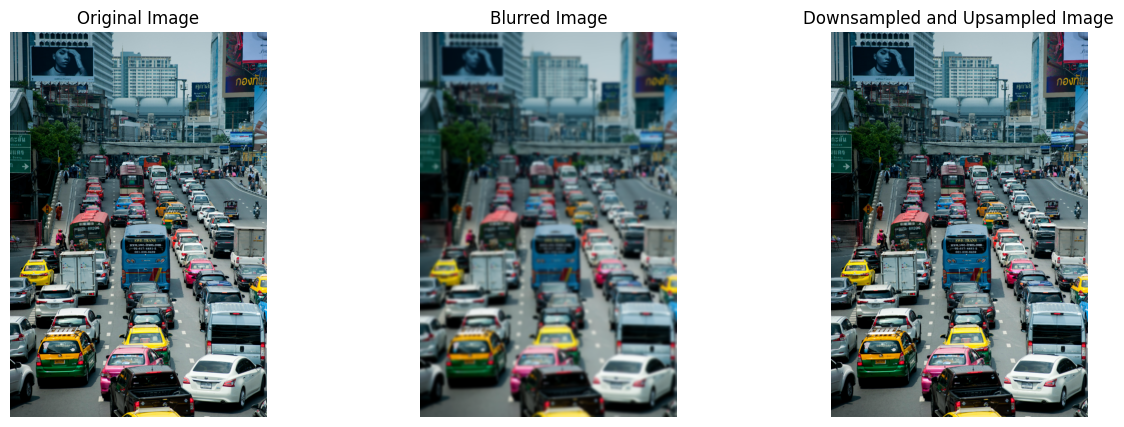

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the original image
image = cv2.imread('your_image.jpg')
height, width = image.shape[:2]

# Apply Gaussian blur
blurred_image = cv2.GaussianBlur(image, (81, 81), 0)

# Downsample and then Upsample
downsampled = cv2.resize(image, (width // 4, height // 4), interpolation=cv2.INTER_LINEAR)
upsampled = cv2.resize(downsampled, (width, height), interpolation=cv2.INTER_NEAREST)

# Convert BGR (OpenCV format) to RGB (matplotlib format) for displaying
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
blurred_image_rgb = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB)
upsampled_rgb = cv2.cvtColor(upsampled, cv2.COLOR_BGR2RGB)

# Print the resolution of each image
print(f"Original Image Resolution: {image.shape[1]}x{image.shape[0]}")
print(f"Blurred Image Resolution: {blurred_image.shape[1]}x{blurred_image.shape[0]}")
print(f"Downsampled and Upsampled Image Resolution: {upsampled.shape[1]}x{upsampled.shape[0]}")

# Display images side by side
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

# Blurred image
plt.subplot(1, 3, 2)
plt.imshow(blurred_image_rgb)
plt.title('Blurred Image')
plt.axis('off')

# Downsampled and upsampled image
plt.subplot(1, 3, 3)
plt.imshow(upsampled_rgb)
plt.title('Downsampled and Upsampled Image')
plt.axis('off')

# Show all images
plt.show()


Original Image Size: 761.38 KB
Compressed Image (Quality 50) Size: 343.33 KB
Compressed Image (Quality 25) Size: 220.49 KB
Compressed Image (Quality 10) Size: 163.75 KB


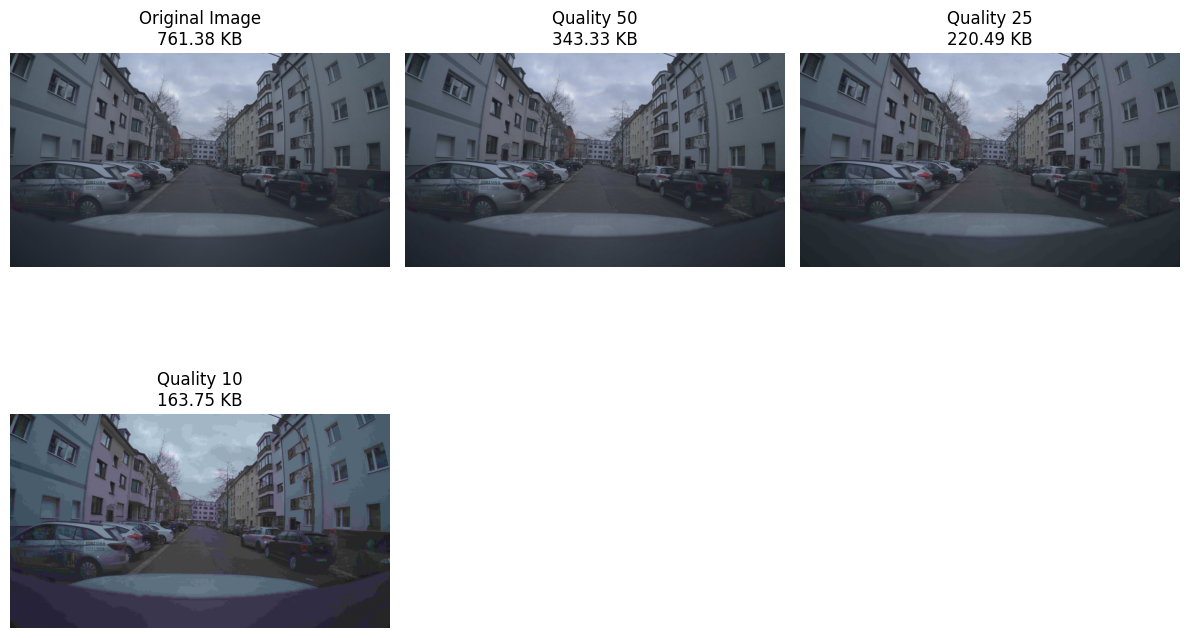

In [17]:
import cv2
import os
import matplotlib.pyplot as plt

# Load the original image
image = cv2.imread('1.jpg')

# Function to get file size in KB
def get_file_size(file_path):
    file_size = os.path.getsize(file_path)  # in bytes
    return file_size / 1024  # convert to KB

# Save the original image to check the size
cv2.imwrite('original_image.jpg', image)

# Print the original image size
original_size = get_file_size('original_image.jpg')
print(f"Original Image Size: {original_size:.2f} KB")

# Initialize a list to store compressed images for visualization
compressed_images = []

# Compress the image with different quality levels and print the sizes
for quality in [50, 25, 10]:
    compressed_file_name = f'compressed_{quality}.jpg'
    cv2.imwrite(compressed_file_name, image, [int(cv2.IMWRITE_JPEG_QUALITY), quality])

    compressed_size = get_file_size(compressed_file_name)
    print(f"Compressed Image (Quality {quality}) Size: {compressed_size:.2f} KB")

    # Load compressed images for visualization
    compressed_image = cv2.imread(compressed_file_name)
    compressed_images.append((compressed_image, quality))

# Convert BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Plot the original and compressed images
plt.figure(figsize=(12, 8))

# Display original image
plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title(f'Original Image\n{original_size:.2f} KB')
plt.axis('off')

# Display compressed images
for i, (compressed_image, quality) in enumerate(compressed_images, start=2):
    compressed_rgb = cv2.cvtColor(compressed_image, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i)
    plt.imshow(compressed_rgb)
    compressed_file_name = f'compressed_{quality}.jpg'
    compressed_size = get_file_size(compressed_file_name)
    plt.title(f'Quality {quality}\n{compressed_size:.2f} KB')
    plt.axis('off')

# Show the plot
plt.tight_layout()
plt.show()
